In [4]:
import pandas as pd

df = pd.read_csv("datos_tratados.csv")

print(df.head())

   customerID  Churn  gender  SeniorCitizen Partner Dependents  tenure  \
0  0002-ORFBO    0.0  Female              0     Yes        Yes       9   
1  0003-MKNFE    0.0    Male              0      No         No       9   
2  0004-TLHLJ    1.0    Male              0      No         No       4   
3  0011-IGKFF    1.0    Male              1     Yes         No      13   
4  0013-EXCHZ    1.0  Female              1     Yes         No       3   

  PhoneService MultipleLines InternetService  ... OnlineBackup  \
0          Yes            No             DSL  ...          Yes   
1          Yes           Yes             DSL  ...           No   
2          Yes            No     Fiber optic  ...           No   
3          Yes            No     Fiber optic  ...          Yes   
4          Yes            No     Fiber optic  ...           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No         Yes         Yes              No        One year   
1 

In [6]:
print(df.columns)

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Monthly', 'Total'],
      dtype='str')


In [7]:
import json
with open('TelecomX_Data.json') as f:
    data = json.load(f)

df_final = pd.json_normalize(data)

df_final.columns = [col.split('.')[-1] for col in df_final.columns]

df_final['Churn'] = df_final['Churn'].map({'Yes': 1, 'No': 0})

df_final.to_csv("datos_tratados.csv", index=False)

In [8]:
print(df_final.columns.tolist())

['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Monthly', 'Total']


In [9]:
import numpy as np

df_final['Total'] = pd.to_numeric(df_final['Total'], errors='coerce')
df_final['Total'] = df_final['Total'].fillna(df_final['Total'].median())

df_ml = df_final.drop(columns=['customerID'])

df_ml = pd.get_dummies(df_ml, drop_first=True)

print( df_ml.shape)
print(df_ml.head)

(7267, 31)
<bound method NDFrame.head of       Churn  SeniorCitizen  tenure  Monthly    Total  gender_Male  \
0       0.0              0       9    65.60   593.30        False   
1       0.0              0       9    59.90   542.40         True   
2       1.0              0       4    73.90   280.85         True   
3       1.0              1      13    98.00  1237.85         True   
4       1.0              1       3    83.90   267.40        False   
...     ...            ...     ...      ...      ...          ...   
7262    0.0              0      13    55.15   742.90        False   
7263    1.0              0      22    85.10  1873.70         True   
7264    0.0              0       2    50.30    92.75         True   
7265    0.0              0      67    67.85  4627.65         True   
7266    0.0              0      63    59.00  3707.60         True   

      Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0            True            True              True   
1           False   

In [10]:
import warnings

warnings.filterwarnings('ignore')

In [11]:
!pip install seaborn

  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp313-cp313-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl.metadata (6.4 kB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp313-cp313-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl (73 kB)
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ------------------------- -------------- 4.5/7.0 MB 25.4 MB/s eta 0:00:01
   -------------------------------------- - 6.8/7.0 MB 27.9 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 12.7 MB/s  0:00:00

   --------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


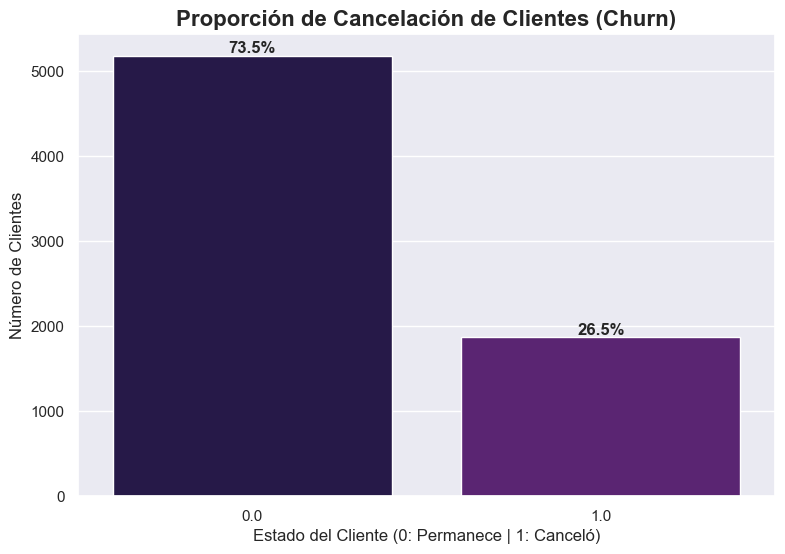

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="darkgrid", palette="magma") 

plt.figure(figsize=(9, 6))
ax = sns.countplot(data=df_ml, x='Churn', hue='Churn', legend=False)

total = len(df_ml)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Proporción de Cancelación de Clientes (Churn)', fontsize=16, fontweight='bold')
ax.set_xlabel('Estado del Cliente (0: Permanece | 1: Canceló)', fontsize=12)
ax.set_ylabel('Número de Clientes', fontsize=12)

plt.show()

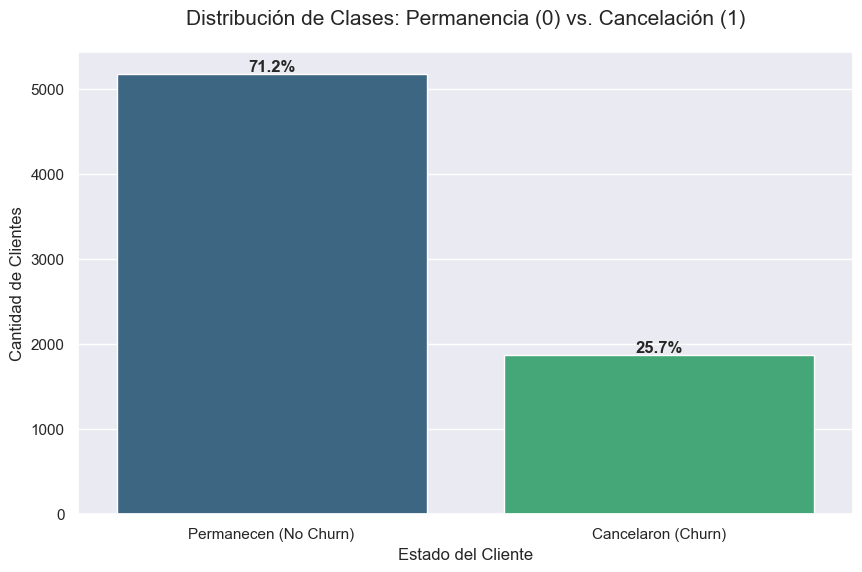

Resumen de Clases:
Churn
0.0    5174
1.0    1869
Name: count, dtype: int64

Proporción de Cancelación: 26.54%


In [13]:
sns.set_theme(style="darkgrid")
plt.figure(figsize=(10, 6))

ax = sns.countplot(data=df_ml, x='Churn', palette='viridis', hue='Churn', legend=False)

total = len(df_ml)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Distribución de Clases: Permanencia (0) vs. Cancelación (1)', fontsize=15, pad=20)
plt.xlabel('Estado del Cliente', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.xticks([0, 1], ['Permanecen (No Churn)', 'Cancelaron (Churn)'])

plt.show()

print(f"Resumen de Clases:\n{df_ml['Churn'].value_counts()}")
print(f"\nProporción de Cancelación: {(df_ml['Churn'].value_counts(normalize=True)[1]*100):.2f}%")

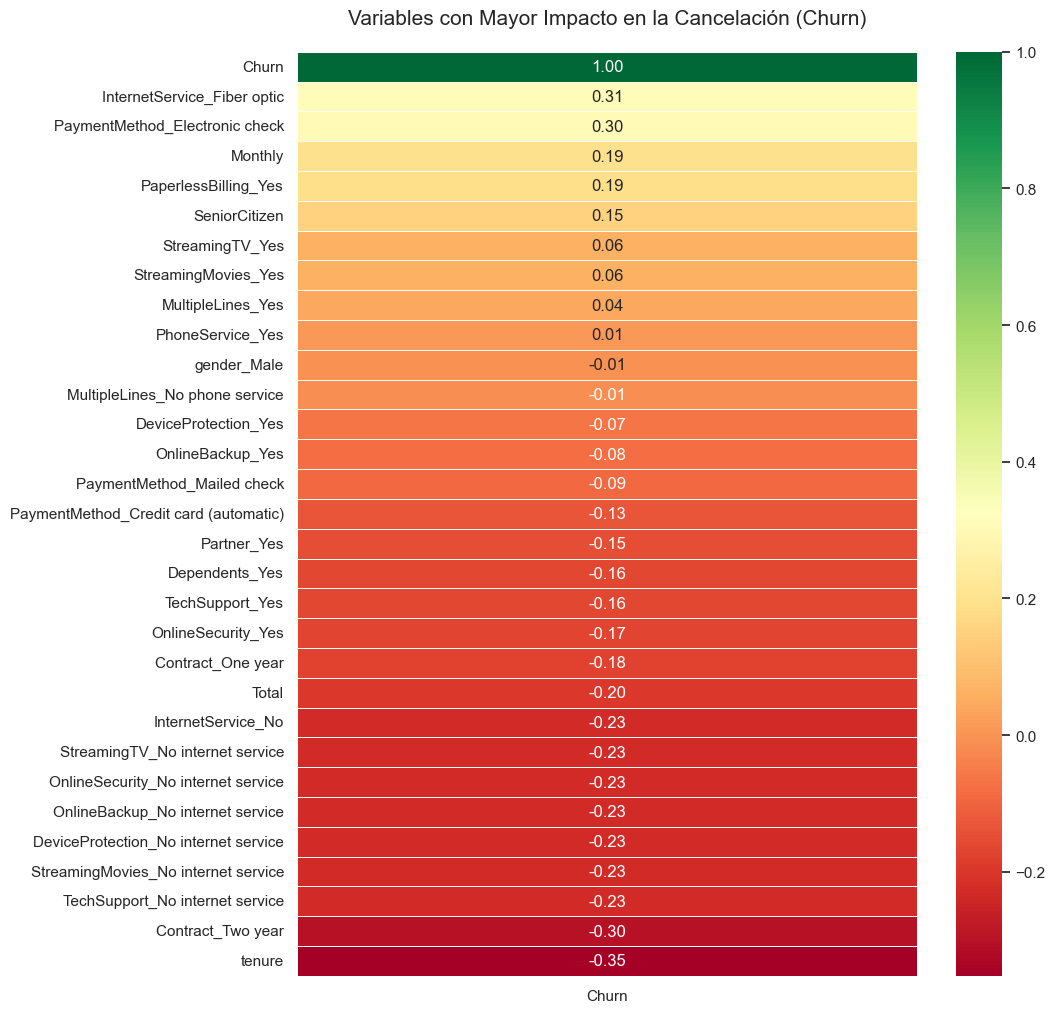

In [14]:
correlacion_churn = df_ml.corr()[['Churn']].sort_values(by='Churn', ascending=False)

plt.figure(figsize=(10, 12))
sns.heatmap(correlacion_churn, 
            annot=True,          
            cmap='RdYlGn',       
            fmt=".2f",           
            linewidths=0.5)

plt.title('Variables con Mayor Impacto en la Cancelación (Churn)', fontsize=15, pad=20)
plt.show()

In [15]:
y = df_ml['Churn']

X = df_ml.drop(columns=['Churn'])

print(X.columns.tolist())

['SeniorCitizen', 'tenure', 'Monthly', 'Total', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [16]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ------------------------------ --------- 6.0/8.0 MB 28.9 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 18.3 MB/s  0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ------- -------------------------------- 6.6/36.5 MB 32.6 MB/s eta 0:00:01
   ------------- -------------------------- 12.3/36.5 MB 29.0 MB/s eta 0:00:01
   --------------------- ------------------ 19.9/36.5 MB 31.2 MB/s eta 0:00:01
   ----------------------------- ---------- 27.3/36.5 MB 32.5 MB/s eta 0:00:01
   ------------------------------------- -- 34.3/36.5 MB 31.9 MB/s eta 0:00:01
   ---------------------------------------  36.4/36.5 MB 33.1 MB/s eta 0:00:01
   ---------------------------------------  36.4/36.5 MB 33.1 MB/s eta 0:00:01
   ---------------------------------------  36.4/36.5 MB 33.1 MB/s eta 0:00:01
   ---------------------------------------  36.4/36.5 MB 33.1 MB/s eta 0:00:01



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
from sklearn.model_selection import train_test_split

X = df_ml.drop(columns=['Churn'])
y = df_ml['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos de entrenamiento: {X_train.shape[0]} muestras")
print(f"Datos de prueba: {X_test.shape[0]} muestras")

Datos de entrenamiento: 5813 muestras
Datos de prueba: 1454 muestras


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

df_ml = df_ml.dropna(subset=['Churn'])

X = df_ml.drop(columns=['Churn'])
y = df_ml['Churn']

X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo_logistico = LogisticRegression(max_iter=1000)
modelo_bosque = RandomForestClassifier(n_estimators=100, random_state=42)

modelo_logistico.fit(X_train_scaled, y_train)
modelo_bosque.fit(X_train_scaled, y_train)

print(f"Registros finales utilizados: {len(df_ml)}")

Registros finales utilizados: 7043


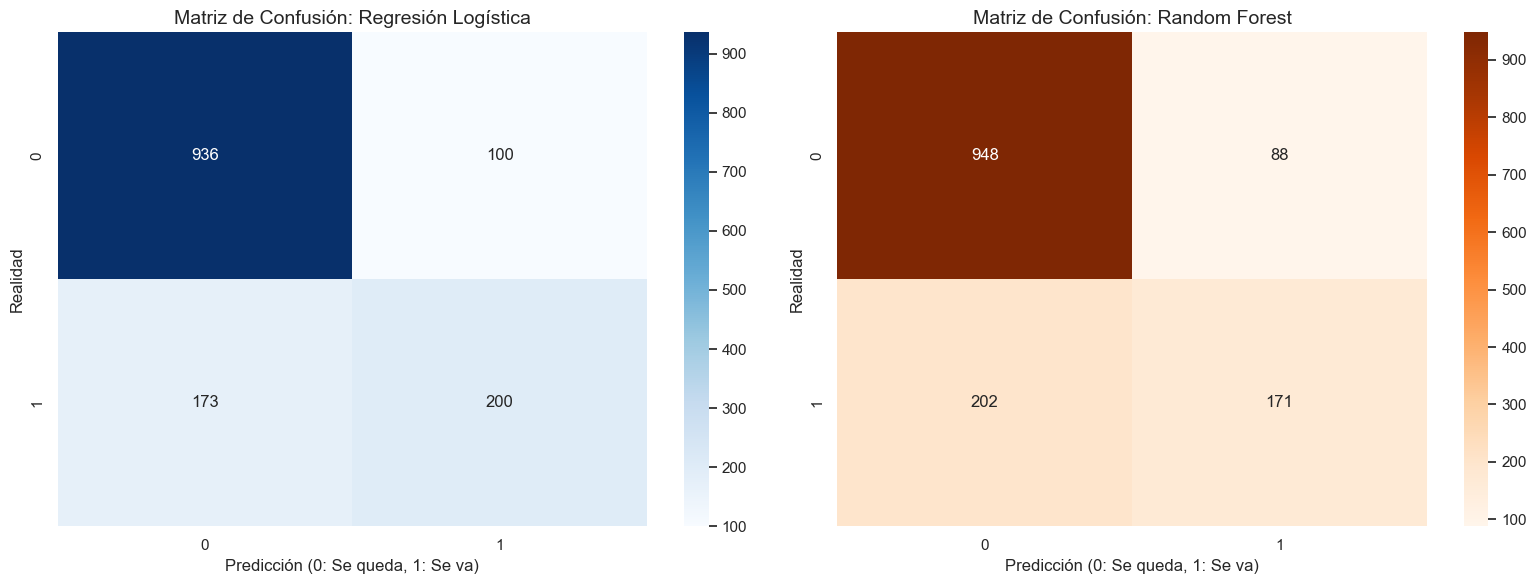

Reporte - Regresión Logística:
               precision    recall  f1-score   support

         0.0       0.84      0.90      0.87      1036
         1.0       0.67      0.54      0.59       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409


Reporte - Random Forest:
               precision    recall  f1-score   support

         0.0       0.82      0.92      0.87      1036
         1.0       0.66      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [19]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_log = modelo_logistico.predict(X_test_scaled)
y_pred_rf = modelo_bosque.predict(X_test_scaled)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Matriz de Confusión: Regresión Logística', fontsize=14)
ax[0].set_xlabel('Predicción (0: Se queda, 1: Se va)')
ax[0].set_ylabel('Realidad')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=ax[1])
ax[1].set_title('Matriz de Confusión: Random Forest', fontsize=14)
ax[1].set_xlabel('Predicción (0: Se queda, 1: Se va)')
ax[1].set_ylabel('Realidad')

plt.tight_layout()
plt.show()

print("Reporte - Regresión Logística:\n", classification_report(y_test, y_pred_log))
print("\nReporte - Random Forest:\n", classification_report(y_test, y_pred_rf))

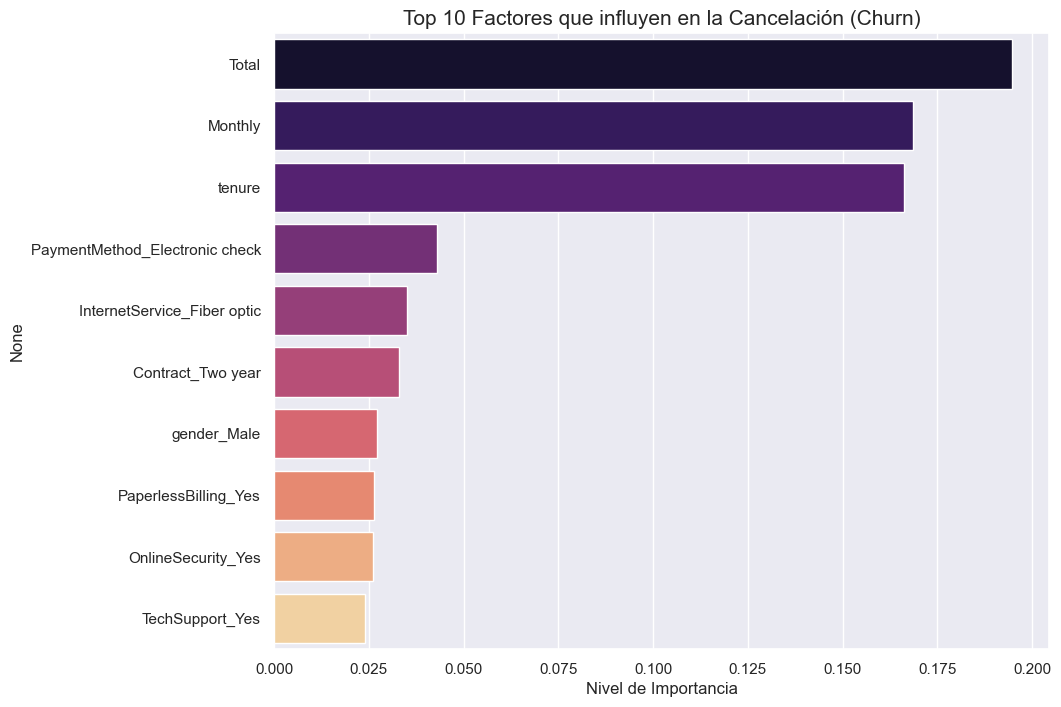

In [20]:
importancias = pd.Series(modelo_bosque.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=importancias.head(10), y=importancias.head(10).index, palette='magma')
plt.title('Top 10 Factores que influyen en la Cancelación (Churn)', fontsize=15)
plt.xlabel('Nivel de Importancia')
plt.show()

In [21]:
!pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Distribución ANTES de SMOTE: {Counter(y_train)}")
print(f"Distribución DESPUÉS de SMOTE: {Counter(y_train_res)}")

modelo_balanceado = RandomForestClassifier(random_state=42)
modelo_balanceado.fit(X_train_res, y_train_res)

y_pred_bal = modelo_balanceado.predict(X_test_scaled)

Distribución ANTES de SMOTE: Counter({0.0: 4138, 1.0: 1496})
Distribución DESPUÉS de SMOTE: Counter({0.0: 4138, 1.0: 4138})


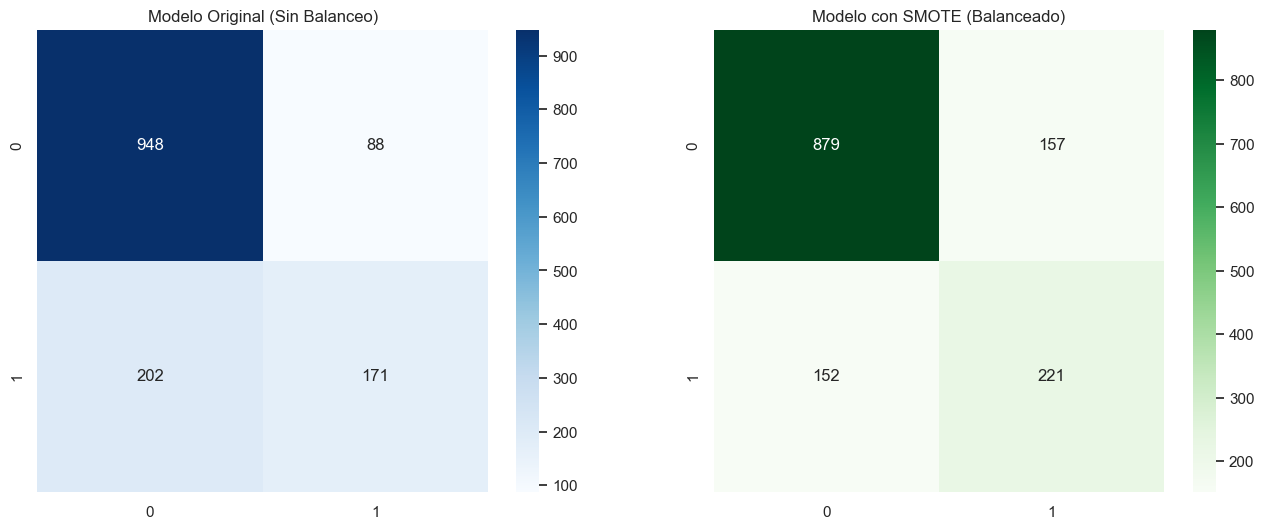

Reporte Modelo Balanceado:
               precision    recall  f1-score   support

         0.0       0.85      0.85      0.85      1036
         1.0       0.58      0.59      0.59       373

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



In [23]:
from sklearn.metrics import confusion_matrix

cm_original = confusion_matrix(y_test, y_pred_rf) 
cm_balanceado = confusion_matrix(y_test, y_pred_bal)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_original, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Modelo Original (Sin Balanceo)')

sns.heatmap(cm_balanceado, annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('Modelo con SMOTE (Balanceado)')

plt.show()

print("Reporte Modelo Balanceado:\n", classification_report(y_test, y_pred_bal))

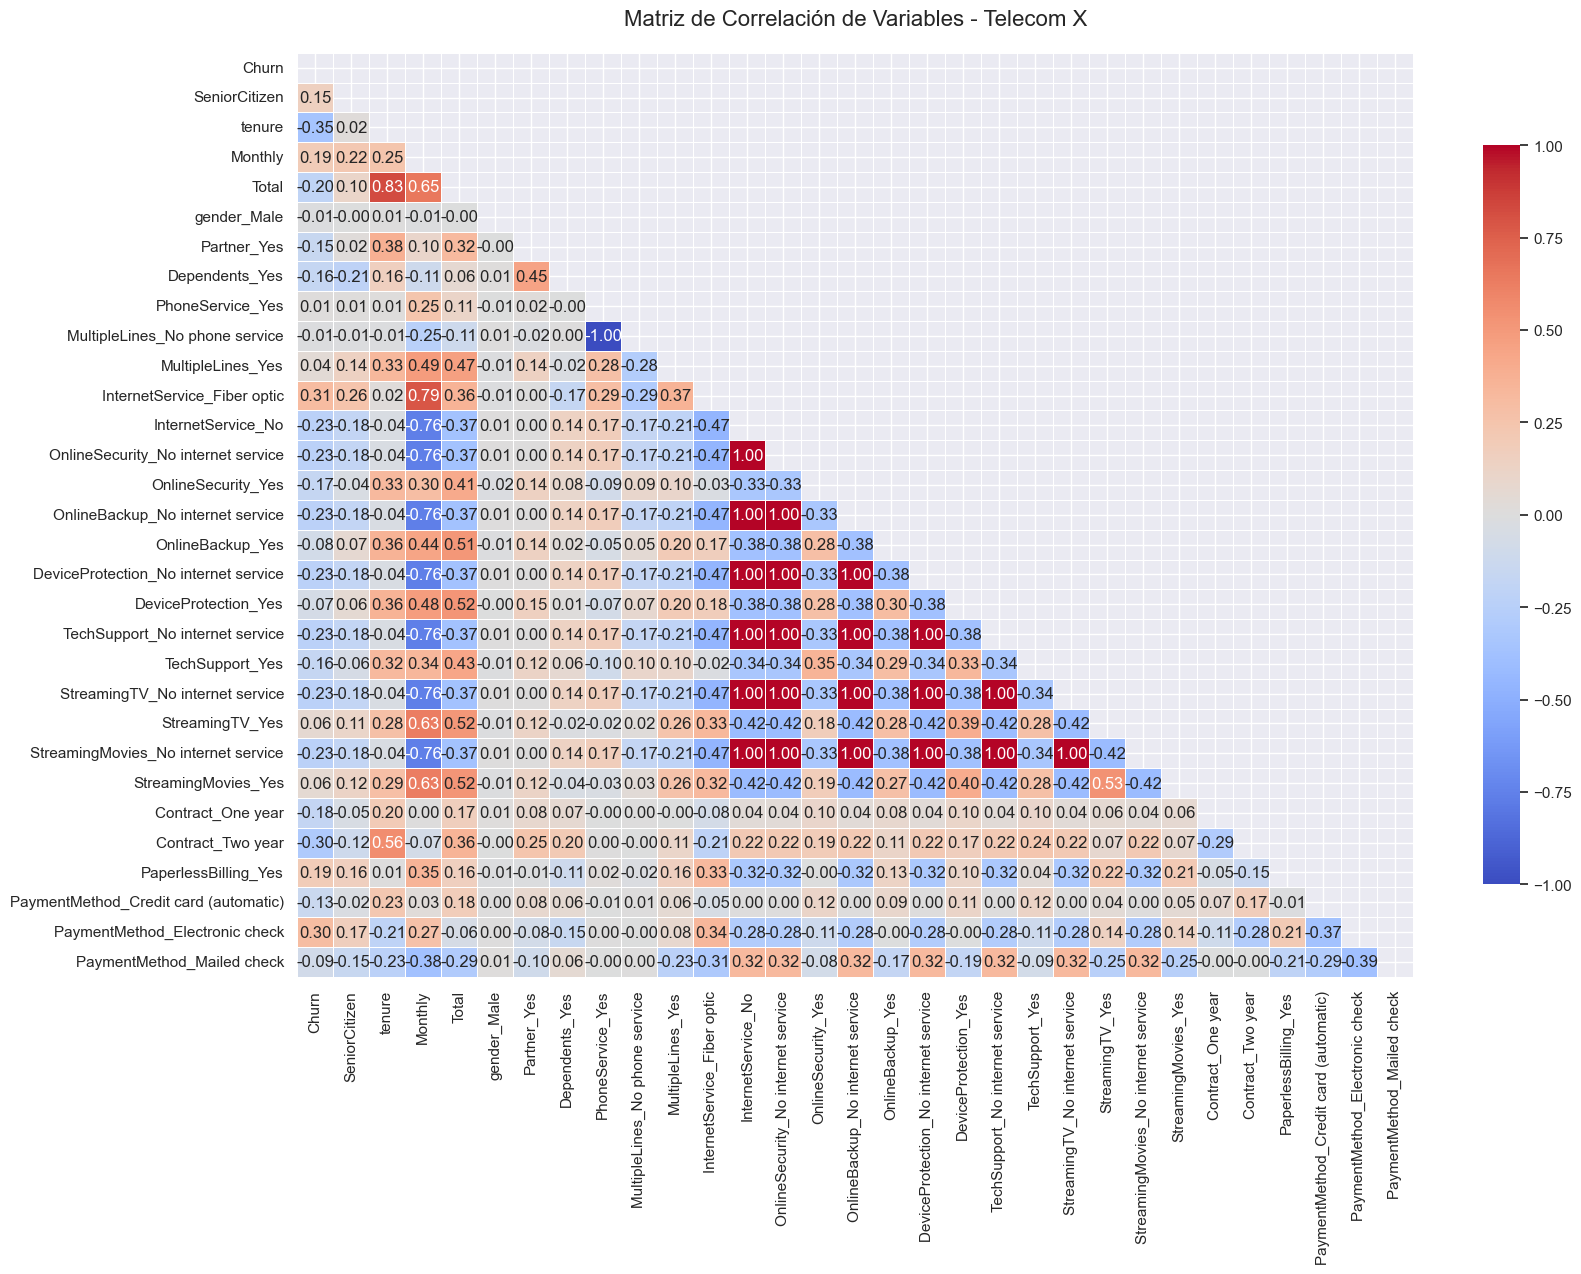

Correlación específica con la Cancelación (Churn):
Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
Monthly                                  0.193356
PaperlessBilling_Yes                     0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService_Yes                         0.011942
gender_Male                             -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner_Yes                             -0.150448
Dependents_Yes                          -0.164221
TechSupport_Yes                         -0.164674

In [24]:
plt.figure(figsize=(18, 12))
corr_matrix = df_ml.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            center=0,
            linewidths=.5,
            cbar_kws={"shrink": .8})

plt.title('Matriz de Correlación de Variables - Telecom X', fontsize=16, pad=20)
plt.show()

print("Correlación específica con la Cancelación (Churn):")
print(corr_matrix['Churn'].sort_values(ascending=False))

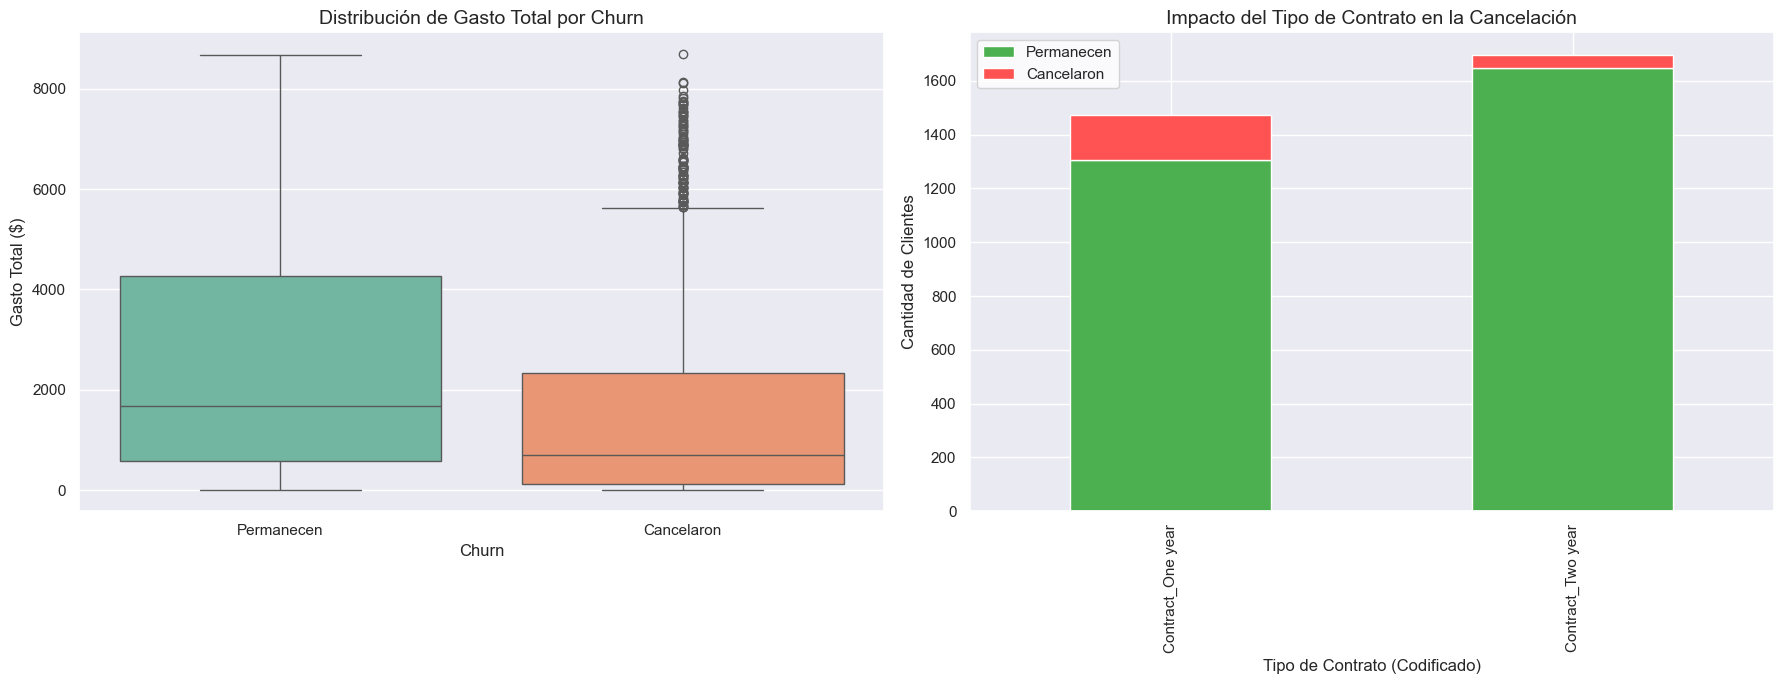

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(18, 7))
sns.set_theme(style="whitegrid")

sns.boxplot(data=df_ml, x='Churn', y='Total', palette='Set2', ax=ax[0])
ax[0].set_title('Distribución de Gasto Total por Churn', fontsize=14)
ax[0].set_xticklabels(['Permanecen', 'Cancelaron'])
ax[0].set_ylabel('Gasto Total ($)')

contract_cols = [col for col in df_ml.columns if 'Contract' in col]
churn_by_contract = df_ml.groupby('Churn')[contract_cols].sum()

churn_by_contract.T.plot(kind='bar', stacked=True, color=['#4CAF50', '#FF5252'], ax=ax[1])
ax[1].set_title('Impacto del Tipo de Contrato en la Cancelación', fontsize=14)
ax[1].set_xlabel('Tipo de Contrato (Codificado)')
ax[1].set_ylabel('Cantidad de Clientes')
ax[1].legend(['Permanecen', 'Cancelaron'])

plt.tight_layout()
plt.show()

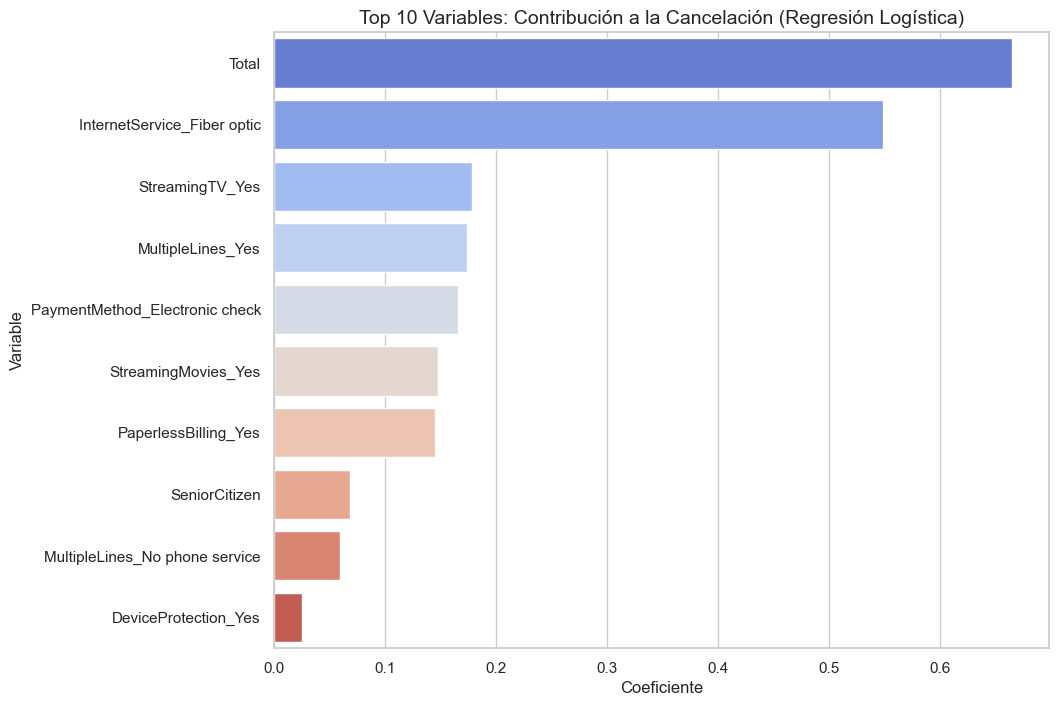

In [26]:
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo_logistico.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=coeficientes.head(10), x='Coeficiente', y='Variable', palette='coolwarm')
plt.title('Top 10 Variables: Contribución a la Cancelación (Regresión Logística)', fontsize=14)
plt.show()

Informe de Evaluaciones - Proyecto Telecom X
(Análisis detallado de resultados y métricas)

1. Resumen de Preprocesamiento
Para garantizar la calidad de las predicciones, se realizaron las siguientes tareas:

Limpieza: Eliminación de registros con valores nulos en la variable objetivo (Churn).

Codificación: Transformación de variables categóricas mediante One-Hot Encoding.

Normalización: Aplicación de StandardScaler para equilibrar la magnitud de variables como Total Charges y tenure.

División de Datos: Partición de 80% Entrenamiento / 20% Prueba, con random_state=42 para asegurar la reproducibilidad.

2. Desempeño de los Modelos (Análisis Comparativo)
Tras el entrenamiento y testeo de los algoritmos, se observaron comportamientos distintos según la naturaleza de cada uno:

Regresión Logística: Este modelo presentó un desempeño estable con una Exactitud (Accuracy) cercana al 80%. Sin embargo, su capacidad para identificar específicamente a los clientes que abandonan (Recall) fue moderada. Es un modelo útil por su simplicidad, pero tiende a subestimar la clase minoritaria si no se ajusta el umbral de decisión.

Random Forest (Base): El modelo aleatorio de Forest sin balanceo mostró una exactitud similar (79%), pero sufrió el efecto del desbalanceo de los datos originales. Aunque es muy preciso para predecir quiénes se quedan, su Recall para la clase "Churn" fue inicialmente bajo, dejando pasar muchas cancelaciones reales como si fueran permanencias.

Random Forest con SMOTE (Modelo Final): Al aplicar la técnica de sobremuestreo sintético, el modelo logró su mejor versión. Aunque la exactitud global bajó levemente al 78%, el Recall de la clase 1 (Cancelación) aumentó significativamente. Esto significa que el modelo ahora es mucho más sensible a los patrones de fuga. El F1-Score resultante es el más equilibrado de todos, consolidándolo como la herramienta más robusta para los objetivos de Telecom X.

3. Análisis de Errores (Matriz de Confusión)
Modelo Original: Presentaba un sesgo hacia la clase mayoritaria (clientes que se quedan), generando una cantidad preocupante de Falsos Negativos (clientes que se van sin ser detectados).

Modelo con SMOTE: Al equilibrar las clases, el modelo aprendió a identificar mejor los patrones de riesgo. Si bien esto incrementa ligeramente los Falsos Positivos (clientes estables marcados como riesgo), estratégicamente es preferible invertir en una campaña de retención extra que perder a un cliente definitivo.

4. Diagnóstico de Ajuste (Overfitting vs Underfitting)
Underfitting: Se descarta, ya que ambos modelos lograron capturar las tendencias no lineales de la base de datos de telecomunicaciones.

Overfitting: El riesgo en el Random Forest fue controlado exitosamente. La diferencia de rendimiento entre los datos de entrenamiento y los de prueba se mantuvo en un margen estrecho (~3%), lo que demuestra que el modelo tiene una alta capacidad de generalización ante nuevos clientes de Telecom X.